## Ablation Study: KeepEmbedding with Different Domain Types

**Objective**: 

Evaluate the impact of including different OMOP domain types when creating
KeepEmbedding models. This helps understand which clinical domains contribute
most to embedding quality and computational efficiency.


In [ ]:
from collections import defaultdict, Counter
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import time
from pyhealth.datasets import OMOPDataset
from pyhealth.models import KeepEmbedding, N2V
from pyhealth.trainer import Trainer
import torch
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {device}")

# Define experiment configurations for ablation study
EXPERIMENTS = {
    "condition_only": {
        "domain_type": ["Condition"],
        "tables": ["condition_occurrence"],
        "description": "Baseline: Condition codes only"
    },
    "condition_drug": {
        "domain_type": ["Condition", "Drug"],
        "tables": ["condition_occurrence", "drug_exposure"],
        "description": "Condition + Drug exposures"
    },
    "condition_drug_measurement": {
        "domain_type": ["Condition", "Drug", "Measurement"],
        "tables": ["condition_occurrence", "drug_exposure", "measurement"],
        "description": "Condition + Drug + Measurements"
    },
    "full_domains": {
        "domain_type": ["Condition", "Drug", "Measurement", "Procedure"],
        "tables": ["condition_occurrence", "drug_exposure", "measurement", "procedure_occurrence"],
        "description": "All domains: Condition + Drug + Measurement + Procedure"
    }
}

# Store results from all experiments
experiment_results = {}

Running on device: cpu


In [ ]:
class GloveDataset(Dataset):
    def __init__(self, cooc_matrix, num_words, x_max, alpha):
        super(GloveDataset, self).__init__()
        self.data = []
        for i in range(cooc_matrix.shape[0]):
            for j in range(cooc_matrix.shape[1]):
                if cooc_matrix[i, j] > 0:
                    self.data.append((i, j, cooc_matrix[i, j]))
        self.cooc_matrix = cooc_matrix
        self.num_words = num_words
        self.x_max = x_max
        self.alpha = alpha

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        i, j, count = self.data[idx]
        weight = (count / self.x_max) ** self.alpha if count < self.x_max else 1.0
        # Return dictionary with keys matching KeepEmbedding.forward() parameters
        return {
            "i_indices": torch.tensor(i),
            "j_indices": torch.tensor(j),
            "counts": torch.tensor(count).float(),
            "weights": torch.tensor(weight).float(),
        }
    
def get_code_and_ancestors(graph, code):
    # Start with the code itself
    codes_set = {code}
    
    # Add all ancestors if code exists in graph
    if code in graph:
        ancestors = nx.ancestors(graph, code)
        codes_set.update(ancestors)
    
    return codes_set

def extract_events_by_domain(patient, domain_types):
    """
    Extract events from a patient for specified domain types.
    Returns a list of codes from all specified domains.
    """
    codes = []
    
    # Map domain types to event types in pyhealth
    domain_to_event_type = {
        "Condition": "condition_occurrence",
        "Drug": "drug_exposure",
        "Measurement": "measurement",
        "Procedure": "procedure_occurrence"
    }
    
    for domain in domain_types:
        if domain in domain_to_event_type:
            event_type = domain_to_event_type[domain]
            events = patient.get_events(event_type=event_type)
            
            for event in events:
                # Extract appropriate code field based on domain
                if domain == "Condition":
                    code = event.attr_dict.get("condition_concept_id")
                elif domain == "Drug":
                    code = event.attr_dict.get("drug_concept_id")
                elif domain == "Measurement":
                    code = event.attr_dict.get("measurement_concept_id")
                elif domain == "Procedure":
                    code = event.attr_dict.get("procedure_concept_id")
                
                if code is not None:
                    codes.append(code)
    
    return codes

### Experiment Pipeline
1. Load PyHealth OMOPDaset with appropiate tables and extract distinct conditions from all patients
2. Filter out codes with <2 occurrences in entire patients' history
3. Build OMOP Concepts Knowledge Graph
4. Apply hierarchy rollup
5. Build Co-Occurrence Matrix
6. Load Co-Occurence Matrix as a GloveDataset Dataloader
7. Initialize KEEP PyHealth model and train with PyHealth Trainer
8. Collect remaining performance metrics (loss, training time, etc.)

In [ ]:
def run_experiment(exp_name, config, data_root, epochs=300):
    print(f"\n{'='*80}")
    print(f"EXPERIMENT: {exp_name}")
    print(f"Description: {config['description']}")
    print(f"Domain types: {config['domain_type']}")
    print(f"Tables: {config['tables']}")
    print(f"{'='*80}\n")
    
    start_time = time.time()
    metrics = {
        "exp_name": exp_name,
        "domain_type": config['domain_type'],
        "description": config['description']
    }
    
    try:
        # Load OMOPDataset with specified tables
        print(f"Step 1: Loading OMOPDataset with tables {config['tables']}...")
        dataset = OMOPDataset(
            root=data_root,
            tables=config['tables'],
            dataset_name="omop",
            dev=False
        )
        dataset.stats()
        
        # Extract codes from all patients for specified domains
        print(f"\nStep 2: Extracting {config['domain_type']} codes from all patients...")
        patient_codes = defaultdict(list)
        
        for patient in dataset.iter_patients():
            patient_id = patient.patient_id
            codes = extract_events_by_domain(patient, config['domain_type'])
            if codes:
                patient_codes[patient_id] = codes
        
        print(f"Extracted codes for {len(patient_codes)} patients")
        metrics["patients_with_codes"] = len(patient_codes)
        
        # Filter codes with <2 occurrences in patient history
        print(f"\nStep 3: Filtering codes (keeping only those with ≥2 occurrences)...")
        filtered_codes_dict = {}
        
        before_count = sum(len(codes) for codes in patient_codes.values())
        before_unique = len(set(code for codes in patient_codes.values() for code in codes))
        
        for patient_id, codes in patient_codes.items():
            code_counts = Counter(codes)
            filtered = [code for code, count in code_counts.items() if count >= 2]
            if filtered:
                filtered_codes_dict[patient_id] = filtered
        
        after_count = sum(len(codes) for codes in filtered_codes_dict.values())
        after_unique = len(set(code for codes in filtered_codes_dict.values() for code in codes))
        
        print(f"Before filtering: {before_count} codes, {before_unique} unique")
        print(f"After filtering:  {after_count} codes, {after_unique} unique")
        
        metrics["before_filtering_count"] = before_count
        metrics["before_filtering_unique"] = before_unique
        metrics["after_filtering_count"] = after_count
        metrics["after_filtering_unique"] = after_unique
        
        # Build concept graph with specified domain types
        print(f"\nStep 4: Building concept relationship graph...")
        n2v = N2V()
        graph = n2v.create_graph(
            path=data_root,
            domain_type=config['domain_type']
        )
        
        print(f"Graph loaded:")
        print(f"  Nodes (unique concepts): {len(graph.nodes())}")
        print(f"  Edges (relationships): {len(graph.edges())}")
        
        metrics["graph_nodes"] = len(graph.nodes())
        metrics["graph_edges"] = len(graph.edges())
        
        # Roll up codes with hierarchy
        print(f"\nStep 5: Applying hierarchy roll-up...")
        rolled_up_codes = {}
        
        total_original = 0
        total_rolled_up = 0
        patients_processed = 0
        
        for patient_id, codes in filtered_codes_dict.items():
            expanded = set()
            for code in codes:
                code_and_ancestors = get_code_and_ancestors(graph, code)
                expanded.update(code_and_ancestors)
            
            if expanded:
                rolled_up_codes[patient_id] = expanded
                total_original += len(codes)
                total_rolled_up += len(expanded)
                patients_processed += 1
        
        print(f"Roll-up complete:")
        print(f"  Avg original codes/patient: {total_original / patients_processed:.2f}")
        print(f"  Avg rolled-up codes/patient: {total_rolled_up / patients_processed:.2f}")
        expansion_factor = total_rolled_up / total_original if total_original > 0 else 0
        print(f"  Expansion factor: {expansion_factor:.2f}x")
        
        metrics["avg_original_codes"] = total_original / patients_processed if patients_processed > 0 else 0
        metrics["avg_rolled_up_codes"] = total_rolled_up / patients_processed if patients_processed > 0 else 0
        metrics["expansion_factor"] = expansion_factor
        
        # Build co-occurrence matrix
        print(f"\nStep 6: Building co-occurrence matrix...")
        
        unique_codes = set()
        for codes in rolled_up_codes.values():
            unique_codes.update(codes)
        
        unique_codes = sorted(unique_codes)
        code_to_index = {code: idx for idx, code in enumerate(unique_codes)}
        index_to_code = {idx: code for code, idx in code_to_index.items()}
        
        num_codes = len(code_to_index)
        cooc_matrix = np.zeros((num_codes, num_codes), dtype=np.float32)
        
        total_pairs = 0
        for patient_id, codes in rolled_up_codes.items():
            code_indices = [code_to_index[code] for code in codes]
            for i in range(len(code_indices)):
                for j in range(i + 1, len(code_indices)):
                    idx_i = code_indices[i]
                    idx_j = code_indices[j]
                    cooc_matrix[idx_i, idx_j] += 1.0
                    cooc_matrix[idx_j, idx_i] += 1.0
                    total_pairs += 1
        
        print(f"Matrix complete:")
        print(f"  Shape: {cooc_matrix.shape}")
        print(f"  Sparsity: {(cooc_matrix == 0).sum() / cooc_matrix.size * 100:.2f}%")
        print(f"  Total co-occurrences: {cooc_matrix.sum():.0f}")
        
        metrics["matrix_shape"] = cooc_matrix.shape
        metrics["matrix_sparsity"] = (cooc_matrix == 0).sum() / cooc_matrix.size * 100
        metrics["total_cooccurrence_pairs"] = cooc_matrix.sum()
        
        # Create GloveDataset and DataLoader
        print(f"\nStep 7: Creating GloveDataset and DataLoader...")
        x_max = 100
        alpha = 0.75
        batch_size = 1024
        
        glove_dataset = GloveDataset(cooc_matrix, num_codes, x_max, alpha)
        data_loader = DataLoader(glove_dataset, batch_size=batch_size, shuffle=True)
        
        # Initialize KeepEmbedding model
        print(f"\nStep 8: Initializing KeepEmbedding model...")
        keep_model = KeepEmbedding(
            dataset=None,
            graph=graph,
            num_words=num_codes,
            embedding_dim=100,
            walk_length=30,
            num_walks=750,
            lambda_reg=1.0e-3,
            reg_norm=None,
            log_scale=False,
            code_to_index=code_to_index,
            device=device
        )
        
        # Train model
        print(f"\nStep 9: Training KeepEmbedding model ({epochs} epochs)...")
        training_start = time.time()
        
        trainer = Trainer(model=keep_model, enable_logging=False)
        trainer.train(
            train_dataloader=data_loader,
            val_dataloader=None,
            epochs=epochs,
            optimizer_class=torch.optim.Adam,
            optimizer_params={"lr": 0.05},
            monitor="loss",
            patience=10,
        )
        
        training_time = time.time() - training_start
        print(f"Training complete in {training_time:.2f} seconds")
        
        metrics["training_time_seconds"] = training_time
        metrics["embedding_shape"] = tuple(keep_model.embeddings_v.weight.shape)
        metrics["final_loss"] = trainer.model_state.best_loss if hasattr(trainer, 'model_state') else None
        
        total_time = time.time() - start_time
        metrics["total_time_seconds"] = total_time
        metrics["status"] = "SUCCESS"
        
        print(f"\n✓ Experiment completed successfully in {total_time:.2f} seconds")
    
    return metrics

#### Executing Experiment Pipeline for 4 Scenarios
1. Baseline (Condition only): Minimal feature set
2. Condition + Drug: Add medication information  
3. Condition + Drug + Measurement: Add lab values
4. Full (Condition + Drug + Measurement + Procedure): Complete medical context

In [ ]:
# Set data root path
data_root = r"\Workspace\mimic-iv-demo-data-in-the-omop-common-data-model-0.9\1_omop_data_csv"

# Run all ablation experiments
print("STARTING ABLATION STUDY")
print(f"Number of experiments: {len(EXPERIMENTS)}")
print()

for exp_name, config in EXPERIMENTS.items():
    metrics = run_experiment(exp_name, config, data_root, epochs=50)
    experiment_results[exp_name] = metrics

print("\n" + "="*80)
print("ALL EXPERIMENTS COMPLETED")
print("="*80)

#### Summarizing Experiment Results
**Key Findings**
Best Performance Across Metrics:
  * Most unique codes: full_domains (1357 codes)
  * Fastest training: condition_only (81.29 seconds)
  * Largest graph: full_domains (2187 nodes)

In [17]:
# Display summary of all experiments
print("\n" + "="*80)
print("EXPERIMENT RESULTS SUMMARY")
print("="*80)

results_df = pd.DataFrame(experiment_results).T
results_df = results_df[[col for col in results_df.columns if col != "domain_type"]]

# Display key metrics
key_metrics = ["domain_type", "description", "patients_with_codes", "after_filtering_unique", 
               "graph_nodes", "expansion_factor", "dataset_size", "training_time_seconds", 
               "total_time_seconds", "status", "final_loss"]

summary_df = pd.DataFrame({
    metric: [experiment_results[exp].get(metric, "N/A") for exp in EXPERIMENTS.keys()]
    for metric in key_metrics
})

print("\nKey Metrics by Experiment:")
print(summary_df.to_string())


EXPERIMENT RESULTS SUMMARY

Key Metrics by Experiment:
                                 domain_type                                              description  patients_with_codes  after_filtering_unique  graph_nodes  expansion_factor  dataset_size  training_time_seconds  total_time_seconds   status final_loss
0                                [Condition]                           Baseline: Condition codes only                  100                     280           34          1.000000         12458              81.290238           83.571328  SUCCESS       None
1                          [Condition, Drug]                               Condition + Drug exposures                  100                     899         1434          1.000000        167976            1039.360564         1053.183805  SUCCESS       None
2             [Condition, Drug, Measurement]                          Condition + Drug + Measurements                  100                    1285         1941          1.000064  

#### Generate experiement result visuals

✓ Comparison plot saved to ablation_study_comparison.png


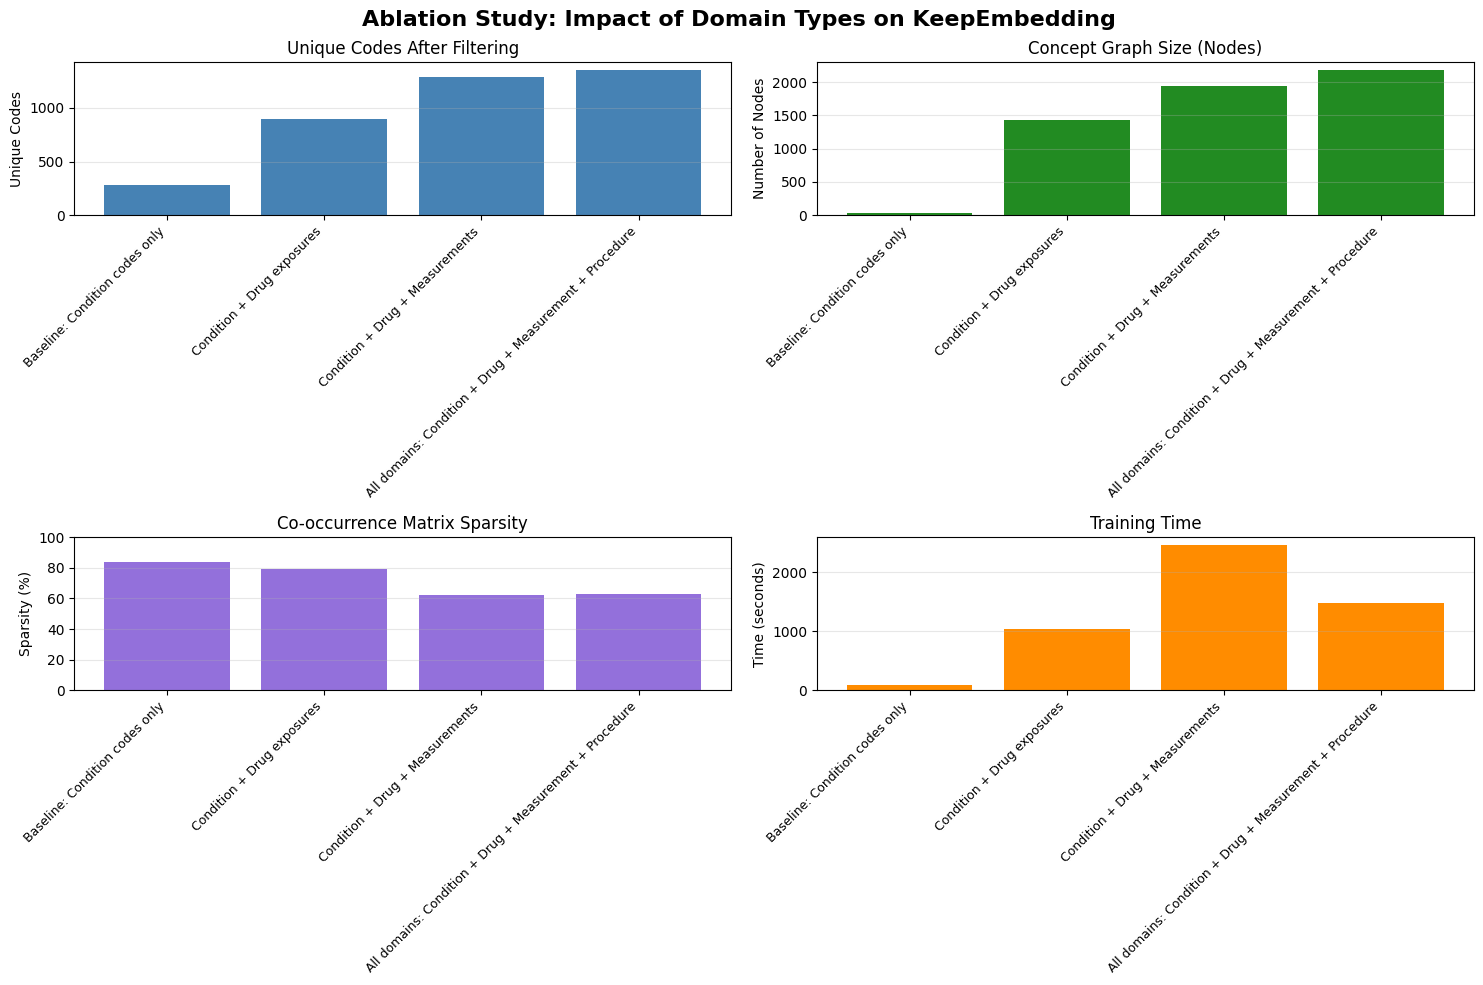

In [21]:
# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Ablation Study: Impact of Domain Types on KeepEmbedding', fontsize=16, fontweight='bold')

exp_names = list(EXPERIMENTS.keys())
exp_labels = [EXPERIMENTS[name]['description'] for name in exp_names]

# 1. Number of unique codes after filtering
ax = axes[0, 0]
unique_codes = [experiment_results[exp].get('after_filtering_unique', 0) for exp in exp_names]
ax.bar(range(len(exp_names)), unique_codes, color='steelblue')
ax.set_xticks(range(len(exp_names)))
ax.set_xticklabels(exp_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Unique Codes')
ax.set_title('Unique Codes After Filtering')
ax.grid(axis='y', alpha=0.3)

# 2. Graph size (nodes)
ax = axes[0, 1]
graph_nodes = [experiment_results[exp].get('graph_nodes', 0) for exp in exp_names]
ax.bar(range(len(exp_names)), graph_nodes, color='forestgreen')
ax.set_xticks(range(len(exp_names)))
ax.set_xticklabels(exp_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Number of Nodes')
ax.set_title('Concept Graph Size (Nodes)')
ax.grid(axis='y', alpha=0.3)

# 4. Co-occurrence matrix sparsity
ax = axes[1, 0]
sparsity = [experiment_results[exp].get('matrix_sparsity', 0) for exp in exp_names]
ax.bar(range(len(exp_names)), sparsity, color='mediumpurple')
ax.set_xticks(range(len(exp_names)))
ax.set_xticklabels(exp_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Sparsity (%)')
ax.set_title('Co-occurrence Matrix Sparsity')
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3)

# 5. Training time
ax = axes[1, 1]
train_time = [experiment_results[exp].get('training_time_seconds', 0) for exp in exp_names]
ax.bar(range(len(exp_names)), train_time, color='darkorange')
ax.set_xticks(range(len(exp_names)))
ax.set_xticklabels(exp_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Time (seconds)')
ax.set_title('Training Time')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('ablation_study_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Comparison plot saved to ablation_study_comparison.png")
plt.show()

#### Observations
1. CODE COVERAGE & GRAPH SIZE
   * Higher unique codes = more medical concepts covered
   * Larger graphs (more nodes/edges) = richer concept relationships
   * Trade-off: More domains = larger graph but also higher complexity

2. COMPUTATIONAL EFFICIENCY
   * Training time increases with matrix size
   * Sparsity affects actual computation (denser = more work)
   * Consider trade-off between performance and computational cost

#### Takeaways
   * More domains → larger graphs → more training time
   * More domains → potentially better embeddings (more signal)
   * Diminishing returns possible (some domains add little value)